# EDA — Dataset sintético IT Ops (TFM)

Notebook principal de experimentación (**Fases 2–5 CRISP-DM**; puente a **Fase 6**). Comparte código con FastAPI (`app/services/`).

→ **Mapa celda ↔ CRISP-DM / OE / Tabla 2:** ver la sección siguiente en este notebook.

**Local / Colab:** no necesitas copiar el CSV a mano en `data/`. Usa la celda **«Seleccionar o subir CSV»** (explorador de archivos en Colab, widget en Jupyter o diálogo en el PC).

**Google Colab:** 1) *Subir proyecto (ZIP)* → 2) *Setup / imports* → 3) *Subir CSV* → 4) *Runtime → Run all* en el resto.

Al final, *Exportar artefactos* genera figuras y `pipeline_config.json` para el backend local (la API y el dashboard React consumen esos parámetros en cada ejecución).

## Mapa CRISP-DM · OE · Tabla 2 (memoria TFM)

Referencia rápida: qué celda cumple qué fase metodológica y qué artefacto genera.

| Celda | Sección | Fase CRISP-DM | OE | Tabla 2 — actividad | Herramientas | Salida / enlace con la app |
|-------|---------|---------------|-----|---------------------|--------------|----------------------------|
| 0 | Intro | — | — | Contexto del notebook | — | — |
| 1 | Mapa CRISP-DM | — | — | Esta tabla (trazabilidad memoria ↔ código) | — | — |
| 2–3 | Setup Colab | **6** Despliegue (entorno) | OE1 | Entorno reproducible en Colab | pip, git/ZIP | Código `app/` para importar igual que FastAPI |
| 4–5 | Setup local | **1** + **6** | OE1 | Pipeline modular compartido notebook ↔ API | Python, `app/services` | Misma lógica que `POST /api/runs` |
| 6–7 | CSV | **2** Comprensión | OE2 | Ingesta del dataset empresarial IT Ops | Pandas, `csv_upload` | CSV → mismo fichero que usa la API |
| 8–9 | §1 Carga | **2** Comprensión | OE2 | Exploración inicial: volumen, primeras filas | Pandas | — |
| 10 | §1 info/describe | **2** Comprensión | OE2 | Tipos, rangos, estadísticos univariantes | Pandas | — |
| 11 | §1 missing | **2** Comprensión | OE2 | Calidad: valores faltantes | Pandas | — |
| 12 | §1 segmentos | **2** Comprensión | OE2 | Distribución / desequilibrios (solo EDA) | Matplotlib | `fig_segment_distribution.png` |
| 13–14 | §2 Features | **3** Preparación | OE2 | Transformación tabular → matriz numérica + escalado | scikit-learn, `it_ops_preprocess` | Mismo preprocesado que `run_pipeline` |
| 15–16 | §3 Comparativa | **4** Modelado | OE3 | Reducción 2D: PCA, UMAP, t-SNE | scikit-learn, UMAP-learn | `fig_reduction_comparison.png` |
| 17–18 | §4 Métricas reducción | **4** + **5** | OE3, OE4 | Clustering HDBSCAN sobre cada proyección + métricas | HDBSCAN, scikit-learn | `tabla_metricas_reduccion.csv` |
| 19–20 | §5 HDBSCAN | **4** Modelado | OE4 | Pipeline principal: UMAP (o CFG) + HDBSCAN | UMAP-learn, HDBSCAN | Silueta, Davies-Bouldin, outliers |
| 21 | §5 scatter | **5** Evaluación | OE5 (evidencia) | Validación visual de clusters | Matplotlib | `fig_hdbscan_umap.png` → memoria Cap. 5 |
| 22–23 | §6 segment | **5** Evaluación | OE6 | Contraste cualitativo (ARI, crosstab; no producción) | scikit-learn | `tabla_crosstab_segment_cluster.csv` |
| 24–25 | §7 Pipeline API | **6** Despliegue | OE1, OE5 | Verificación: mismo código que FastAPI | `run_pipeline` | Resultado = lo que guarda PostgreSQL vía API |
| 26–27 | §8 Exportar | **5** + **6** | OE3–OE6 | Fijar hiperparámetros y evidencias para TFM/backend | JSON | `pipeline_config.json` → API lee automáticamente |
| 28 | ZIP Colab | **6** Despliegue | OE5 | Trasladar artefactos al repo local | Colab `files` | Descomprimir en `notebooks/artifacts/` |

### Flujo resumido (Figura 4 memoria)

```
Fase 2 (celdas 8–12)  →  Fase 3 (13–14)  →  Fase 4 (15–20)  →  Fase 5 (17–18, 21–23, 27)  →  Fase 6 (25, 27, app React)
```

### Qué NO hace este notebook (va en la aplicación web)

| Actividad memoria | Dónde |
|-------------------|--------|
| Embeddings texto/imagen (CLIP, sentence-transformers) | API modalidades `texto` / `imagen` / `multimodal` |
| Dashboard Plotly interactivo (OE5) | Frontend React |
| Persistencia de runs (OE6) | FastAPI + PostgreSQL |
| Exploración sin código por el analista | Capa de interacción (Fase 6) |


## Colab — paso 1: sube el ZIP del proyecto

Comprime en tu PC la carpeta **`eda-platform-backend`** (debe incluir `app/`, `scripts/`, `notebooks/`).  
Ejecuta la celda siguiente → elige el `.zip` → listo (descomprime y configura solo).

In [1]:
import os
import sys
import zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules


def _find_backend_root() -> Path | None:
  candidates = [
    Path("/content/eda-platform-backend"),
    Path("/content"),
    Path.cwd(),
  ]
  for base in candidates:
    for p in [base.resolve(), *base.resolve().parents]:
      if (p / "app" / "services").is_dir():
        return p
  content = Path("/content")
  if content.is_dir():
    for child in content.iterdir():
      if not child.is_dir() or child.name.startswith("."):
        continue
      if (child / "app" / "services").is_dir():
        return child.resolve()
      nested = child / "eda-platform-backend"
      if nested.is_dir() and (nested / "app" / "services").is_dir():
        return nested.resolve()
  return None


if IN_COLAB:
  %pip install -q pandas numpy scikit-learn umap-learn hdbscan matplotlib seaborn Faker ipywidgets

  ROOT = _find_backend_root()
  if ROOT is None:
    for zpath in Path("/content").glob("*.zip"):
      with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall("/content")
      print("Descomprimido (ya estaba en Colab):", zpath.name)
    ROOT = _find_backend_root()

  if ROOT is None:
    from google.colab import files

    print("Selecciona eda-platform-backend.zip (carpeta del proyecto con app/ dentro)")
    for name, data in files.upload().items():
      if not name.lower().endswith(".zip"):
        print("Omitido (no es ZIP):", name)
        continue
      dest = Path("/content") / name
      dest.write_bytes(data)
      with zipfile.ZipFile(dest, "r") as zf:
        zf.extractall("/content")
      print("Descomprimido:", name)
    ROOT = _find_backend_root()

  if ROOT is None:
    raise FileNotFoundError(
      "No se encontró app/services tras descomprimir. "
      "Comprime la carpeta eda-platform-backend entera (no solo app/ suelta) y vuelve a ejecutar."
    )

  os.chdir(ROOT)
  if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

  print("Proyecto listo:", ROOT)
  print("Siguiente → celda «Setup / imports» y luego «Seleccionar o subir CSV».")
else:
  print("No estás en Colab — salta esta celda y usa la siguiente.")

No estás en Colab — salta esta celda y usa la siguiente.


## Setup / imports (Colab paso 2 · local)

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

IN_COLAB = "google.colab" in sys.modules


def _notebook_dir() -> Path | None:
  try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is None:
      return None
    for key in ("__vsc_ipynb_file__", "__file__"):
      p = ip.user_ns.get(key)
      if p:
        return Path(p).resolve().parent
  except Exception:
    pass
  return None


def find_project_root() -> Path:
  starts: list[Path] = []
  nb = _notebook_dir()
  if nb is not None:
    starts.append(nb)
  starts.append(Path.cwd().resolve())
  if IN_COLAB:
    starts.extend([Path("/content/eda-platform-backend"), Path("/content")])
  seen: set[Path] = set()
  for start in starts:
    for candidate in [start.resolve(), *start.resolve().parents]:
      if candidate in seen:
        continue
      seen.add(candidate)
      if (candidate / "app" / "services").is_dir():
        return candidate
  hint = (
    "En Colab: ejecuta primero la celda «Subir proyecto (ZIP)»."
    if IN_COLAB
    else "Ejecuta desde la raíz de eda-platform-backend o abre el notebook en notebooks/."
  )
  raise FileNotFoundError(f"No se encontró app/services (cwd={Path.cwd()}). {hint}")


_prev_root = globals().get("ROOT")
if _prev_root is None or not (Path(_prev_root) / "app" / "services").is_dir():
  ROOT = find_project_root()
else:
  ROOT = Path(_prev_root).resolve()

if str(ROOT) not in sys.path:
  sys.path.insert(0, str(ROOT))

from app.services.pipeline.it_ops_preprocess import load_it_ops_dataframe, dataframe_to_features
from app.services.pipeline.pipeline_config import (
  artifacts_dir,
  load_pipeline_config,
  save_pipeline_config,
)
from app.services.pipeline.pipeline_core import (
  reduce_2d,
  cluster_hdbscan,
  cluster_dbscan,
  compute_metrics,
  scale_features,
)
from sklearn.neighbors import NearestNeighbors

from app.services.datasets.csv_upload import resolve_csv_path

sns.set_theme(style="whitegrid")
SEED = 42
DEFAULT_CSV = ROOT / "data" / "it_ops_synthetic_10000.csv"
GENERATE_SCRIPT = ROOT / "scripts" / "generate_it_ops_dataset.py"
ART = artifacts_dir()
ART.mkdir(parents=True, exist_ok=True)
CFG = load_pipeline_config()
CSV = None  # se define en la celda siguiente

print("ROOT:", ROOT)
print("Artefactos:", ART)
print("Ejecuta la celda «Seleccionar o subir CSV» antes del análisis.")

ROOT: C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\eda-platform-backend
Artefactos: C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\eda-platform-backend\notebooks\artifacts
Ejecuta la celda «Seleccionar o subir CSV» antes del análisis.


## Seleccionar o subir CSV

Elige cómo cargar los datos (válido en **Colab**, **Jupyter local** y **VS Code**):

| `DATA_MODE` | Comportamiento |
|-------------|----------------|
| `"upload"` | **Recomendado en Colab** — diálogo para subir `.csv` |
| `"default"` | Usa `data/it_ops_synthetic_10000.csv` si ya existe |
| `"generate"` | Crea el sintético con el script del repo |
| `"path"` | Pide la ruta por teclado |

In [3]:
# Cambia solo esta línea si quieres otro modo
DATA_MODE = "default"  # upload | default | generate | path

if "google.colab" in sys.modules:
  %pip install -q ipywidgets

CSV = resolve_csv_path(
  mode=DATA_MODE,
  artifacts_dir=ART,
  default_path=DEFAULT_CSV,
  generate_script=GENERATE_SCRIPT,
)

print("CSV activo:", CSV)
print("Tamaño:", CSV.stat().st_size // 1024, "KB")

CSV activo: C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\eda-platform-backend\data\it_ops_synthetic_10000.csv
Tamaño: 2239 KB


## 1. Carga y comprensión de los datos

In [4]:
df = load_it_ops_dataframe(CSV)
print(df.shape)
df.head()

(10000, 36)

,client_id,client_name,contract_reference,sector,service_line,support_channel,active_users,monthly_tickets,critical_incidents,avg_resolution_hours,...,security_incidents,downtime_hours,data_volume_tb,integration_count,license_utilization,patch_compliance_rate,first_contact_resolution,nps_score,backup_frequency_score,segment
0,C00001,Banca Privada OLMJ S.L.N.E,CTR-59338,public_sector,cloud,chat,858,108,7,50.19,...,2,14.51,11.75,12,0.8073,0.7554,0.6984,3.2,8.58,critical_incidents
1,C00002,Suministros BL S.Coop.,CTR-72352,telecom,cybersecurity,chat,1373,130,3,6.66,...,4,7.55,5.16,11,0.6555,0.7399,0.6022,22.4,8.11,high_volume
2,C00003,Grupo Rivas S.A.T.,CTR-98348,public_sector,cybersecurity,email,3703,65,1,18.23,...,1,32.34,8.12,2,0.9116,0.9211,0.5195,14.2,8.35,complex_projects
3,C00004,Alimentación Cuervo y asociados S.Com.,CTR-49343,banking,software_dev,phone,2139,67,2,45.91,...,0,23.24,7.15,19,0.6376,0.7476,0.7375,51.5,8.54,critical_incidents
4,C00005,Fábrica Navarro S.A.,CTR-17816,banking,cloud,phone,780,13,0,7.82,...,2,0.35,12.38,10,0.7897,0.9035,0.7271,29.1,9.18,stable


In [5]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   client_id                 10000 non-null  object 
 1   client_name               10000 non-null  object 
 2   contract_reference        10000 non-null  object 
 3   sector                    10000 non-null  object 
 4   service_line              10000 non-null  object 
 5   support_channel           10000 non-null  object 
 6   active_users              10000 non-null  int64  
 7   monthly_tickets           10000 non-null  int64  
 8   critical_incidents        10000 non-null  int64  
 9   avg_resolution_hours      10000 non-null  float64
 10  sla_breach_rate           10000 non-null  float64
 11  reopen_rate               9307 non-null   float64
 12  escalation_rate           9331 non-null   float64
 13  platform_usage_score      9316 non-null   float64
 14  change_

,count,mean,std,min,25%,50%,75%,max
active_users,10000.0,2013.993300,1296.178872,10.0000,892.00000,1873.50000,2748.500000,9.306000e+03
monthly_tickets,10000.0,77.091600,60.506192,0.0000,28.00000,68.00000,107.000000,5.520000e+02
critical_incidents,10000.0,4.637200,10.800687,0.0000,0.00000,2.00000,5.000000,1.500000e+02
avg_resolution_hours,10000.0,20.199126,19.197619,0.5000,8.56000,13.72000,24.522500,1.605300e+02
sla_breach_rate,10000.0,0.112224,0.115391,0.0000,0.03450,0.07425,0.149600,8.401000e-01
reopen_rate,9307.0,0.089691,0.098050,0.0000,0.02620,0.05700,0.117600,9.228000e-01
escalation_rate,9331.0,0.067667,0.075193,0.0000,0.01870,0.04210,0.089550,6.587000e-01
platform_usage_score,9316.0,3.984735,2.542689,0.0000,1.95000,3.66000,5.670000,1.000000e+01
change_requests,10000.0,15.570200,9.098019,0.0000,8.00000,14.00000,21.000000,6.100000e+01
project_complexity,10000.0,5.334110,2.326931,1.0000,3.33750,5.14500,7.330000,1.000000e+01


In [6]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

automation_rate             697
reopen_rate                 693
platform_usage_score        684
knowledge_base_usage        670
escalation_rate             669
first_contact_resolution    635
dtype: int64

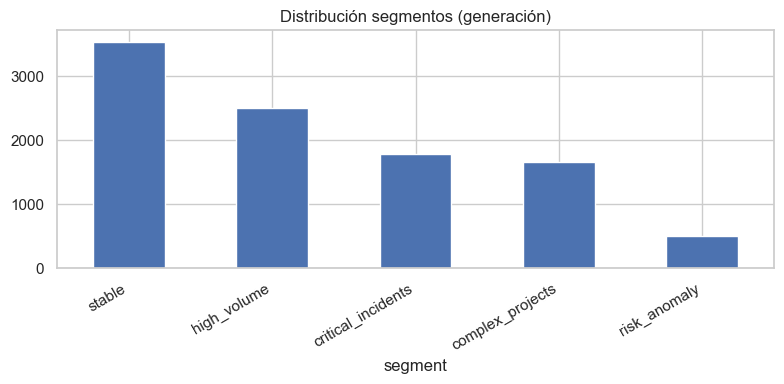

In [7]:
if "segment" in df.columns:
  fig, ax = plt.subplots(figsize=(8, 4))
  df["segment"].value_counts().plot(kind="bar", ax=ax, title="Distribución segmentos (generación)")
  plt.xticks(rotation=30, ha="right")
  plt.tight_layout()
  fig.savefig(ART / "fig_segment_distribution.png", dpi=150, bbox_inches="tight")
  plt.show()

## 2. Matriz de características

In [8]:
X, preprocessor, meta, _groups = dataframe_to_features(df)
X_scaled = scale_features(X)
print("X shape:", X_scaled.shape)

X shape: (10000, 26)


## 3. Comparativa reducción 2D (PCA, UMAP, t-SNE)

C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


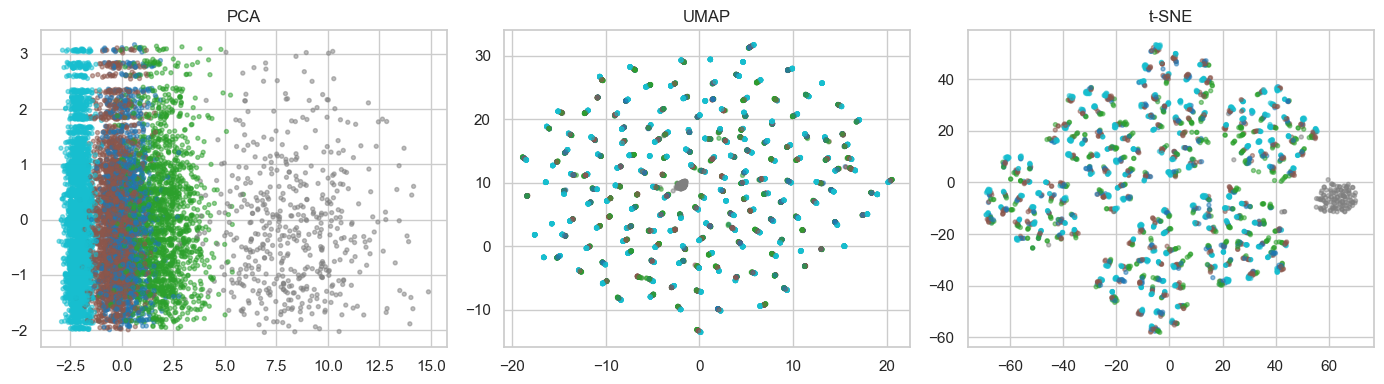

In [9]:
N_TSNE = 2500
df_tsne = df.sample(n=min(N_TSNE, len(df)), random_state=SEED) if len(df) > N_TSNE else df
X_t, _, _, _ = dataframe_to_features(df_tsne)
X_t = scale_features(X_t)

methods = ["PCA", "UMAP", "t-SNE"]
projections = {}
for m in methods:
  src = X_t if m == "t-SNE" else X_scaled
  frame = df_tsne if m == "t-SNE" else df
  projections[m] = reduce_2d(src, m, SEED, config=CFG)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, m in zip(axes, methods):
  coords = projections[m]
  seg = (df_tsne if m == "t-SNE" else df)["segment"].values if "segment" in df.columns else None
  c = pd.Categorical(seg).codes if seg is not None else "C0"
  ax.scatter(coords[:, 0], coords[:, 1], c=c, s=8, alpha=0.5, cmap="tab10")
  ax.set_title(m)
fig.savefig(ART / "fig_reduction_comparison.png", dpi=150, bbox_inches="tight")
plt.tight_layout()
plt.show()

## 4. Métricas por método de reducción (tabla para TFM)

In [10]:
rows = []
for m in methods:
  coords_m = projections[m]
  lab_m = cluster_hdbscan(coords_m, config=CFG)
  met_m = compute_metrics(coords_m, lab_m)
  n_out = int((lab_m == -1).sum())
  n_cl = len(set(lab_m.tolist())) - (1 if -1 in lab_m else 0)
  rows.append({
    "reduction": m,
    "silhouette": met_m.silhouette,
    "davies_bouldin": met_m.davies_bouldin,
    "outliers": n_out,
    "outliers_pct": round(100 * n_out / len(lab_m), 2),
    "n_clusters": n_cl,
  })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(ART / "tabla_metricas_reduccion.csv", index=False)
metrics_df

,reduction,silhouette,davies_bouldin,outliers,outliers_pct,n_clusters
0,PCA,0.701656,0.390253,195,1.95,2
1,UMAP,0.845056,0.194961,74,0.74,306
2,t-SNE,0.585699,0.584633,203,8.12,98


## 5. Clustering HDBSCAN (método principal: UMAP)

In [11]:
METHOD = CFG.get("reduction_method", "UMAP")
coords = reduce_2d(X_scaled, METHOD, SEED, config=CFG)
labels = cluster_hdbscan(coords, config=CFG)
metrics = compute_metrics(coords, labels)
n_out = int((labels == -1).sum())
n_clusters = len(set(labels.tolist())) - (1 if -1 in labels else 0)

print("Método:", METHOD)
print("Silhouette:", metrics.silhouette)
print("Davies-Bouldin:", metrics.davies_bouldin)
print("Outliers (-1):", n_out, f"({100*n_out/len(labels):.1f}%)")
print("Clusters:", n_clusters)

C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Método: UMAP
Silhouette: 0.8450555801391602
Davies-Bouldin: 0.19496135332558015
Outliers (-1): 74 (0.7%)
Clusters: 306


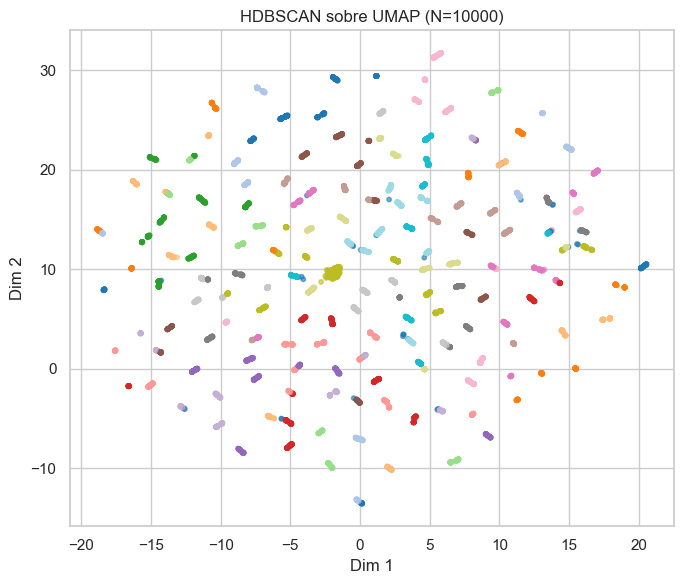

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=labels, s=10, cmap="tab20", alpha=0.6)
ax.set_title(f"HDBSCAN sobre {METHOD} (N={len(labels)})")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
plt.tight_layout()
fig.savefig(ART / "fig_hdbscan_umap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5b. Comparativa HDBSCAN vs DBSCAN (baseline)

DBSCAN se ejecuta sobre la **misma proyección 2D** (`coords`) solo para comparar métricas. HDBSCAN sigue siendo el algoritmo principal del pipeline y de la plataforma.

Calibración de `eps`: gráfico k-distance (k = min_samples) + grid pequeño; el valor elegido se exporta a `pipeline_config.json`.

DBSCAN calibrado: eps=0.027, min_samples=5


,algorithm,n_clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz,ari,nmi
0,HDBSCAN,306,0.74,0.845056,0.194961,132.067557,0.020110,0.230010
1,DBSCAN,393,10.14,0.849969,0.214965,136.687695,0.006828,0.228027


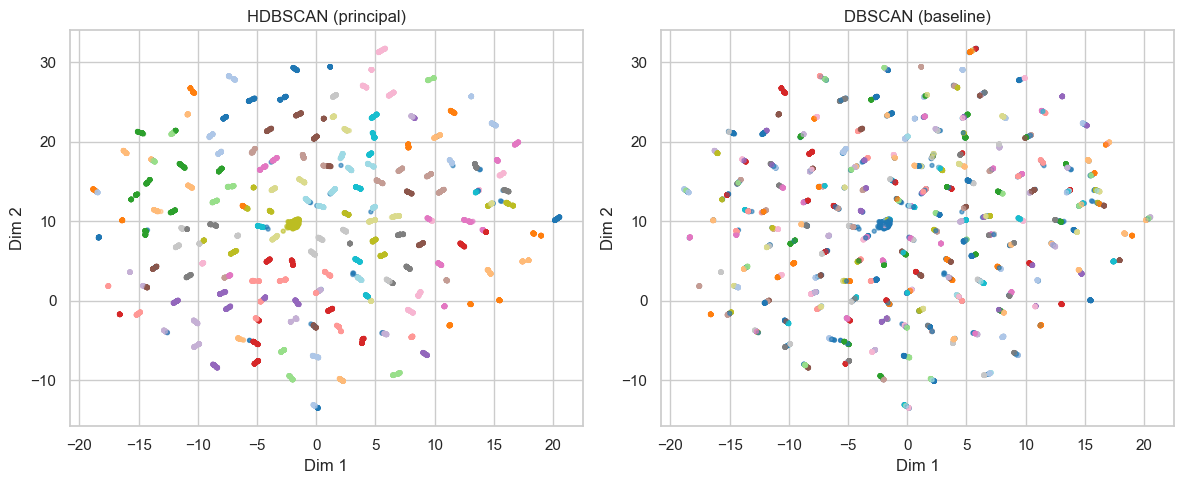

In [13]:
from sklearn.metrics import silhouette_score

hdb_cfg = CFG.get("hdbscan", {})
db_min_samples = int(hdb_cfg.get("min_samples") or 5)

# k-distance para orientar eps (documentación TFM)
nn = NearestNeighbors(n_neighbors=db_min_samples)
nn.fit(coords)
k_dist = np.sort(nn.kneighbors(coords)[0][:, -1])
knee_eps = float(np.percentile(k_dist, 90))

eps_candidates = sorted(set([round(knee_eps * factor, 3) for factor in (0.5, 0.75, 1.0, 1.25, 1.5)]))
best_eps = knee_eps
best_score = -1.0
for eps in eps_candidates:
  trial_cfg = {**CFG, "dbscan": {"eps": eps, "min_samples": db_min_samples}}
  trial_labels = cluster_dbscan(coords, config=trial_cfg)
  n_cl = len({int(x) for x in trial_labels.tolist() if int(x) >= 0})
  mask = trial_labels >= 0
  if n_cl < 2 or mask.sum() < n_cl + 1:
    continue
  try:
    score = float(silhouette_score(coords[mask], trial_labels[mask]))
  except ValueError:
    continue
  if score > best_score:
    best_score = score
    best_eps = eps

CFG = {**CFG, "dbscan": {"eps": best_eps, "min_samples": db_min_samples}}
print(f"DBSCAN calibrado: eps={best_eps}, min_samples={db_min_samples}")

labels_db = cluster_dbscan(coords, config=CFG)
metrics_db = compute_metrics(
  coords,
  labels_db,
  X_features=X_scaled,
  include_stability=False,
)
ref_segment = df["segment"].to_numpy() if "segment" in df.columns else None
if ref_segment is not None:
  metrics_hdb_ref = compute_metrics(
    coords,
    labels,
    X_features=X_scaled,
    reference_labels=ref_segment,
    include_stability=False,
  )
  metrics_db_ref = compute_metrics(
    coords,
    labels_db,
    X_features=X_scaled,
    reference_labels=ref_segment,
    include_stability=False,
  )
else:
  metrics_hdb_ref = metrics
  metrics_db_ref = metrics_db

clustering_rows = [
  {
    "algorithm": "HDBSCAN",
    "n_clusters": metrics_hdb_ref.n_clusters,
    "noise_pct": metrics_hdb_ref.noise_pct,
    "silhouette": metrics_hdb_ref.silhouette,
    "davies_bouldin": metrics_hdb_ref.davies_bouldin,
    "calinski_harabasz": metrics_hdb_ref.calinski_harabasz,
    "ari": metrics_hdb_ref.ari,
    "nmi": metrics_hdb_ref.nmi,
  },
  {
    "algorithm": "DBSCAN",
    "n_clusters": metrics_db_ref.n_clusters,
    "noise_pct": metrics_db_ref.noise_pct,
    "silhouette": metrics_db_ref.silhouette,
    "davies_bouldin": metrics_db_ref.davies_bouldin,
    "calinski_harabasz": metrics_db_ref.calinski_harabasz,
    "ari": metrics_db_ref.ari,
    "nmi": metrics_db_ref.nmi,
  },
]
clustering_df = pd.DataFrame(clustering_rows)
clustering_df.to_csv(ART / "tabla_metricas_clustering.csv", index=False)
display(clustering_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, lab, title in [
  (axes[0], labels, "HDBSCAN (principal)"),
  (axes[1], labels_db, "DBSCAN (baseline)"),
]:
  ax.scatter(coords[:, 0], coords[:, 1], c=lab, s=8, cmap="tab20", alpha=0.6)
  ax.set_title(title)
  ax.set_xlabel("Dim 1")
  ax.set_ylabel("Dim 2")
plt.tight_layout()
fig.savefig(ART / "fig_clustering_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Validación interna (`segment` — solo evaluación, no producción)

In [14]:
if "segment" in df.columns:
  from sklearn.metrics import adjusted_rand_score

  mask = labels >= 0
  ari = adjusted_rand_score(df.loc[mask, "segment"], labels[mask])
  print(f"Adjusted Rand Index (sin outliers): {ari:.3f}")
  ct = pd.crosstab(df["segment"], labels, rownames=["segment"], colnames=["cluster"])
  ct.to_csv(ART / "tabla_crosstab_segment_cluster.csv")
  display(ct)

Adjusted Rand Index (sin outliers): 0.020


cluster,-1,0,1,2,3,4,5,6,7,8,...,296,297,298,299,300,301,302,303,304,305
segment,,,,,,,,,,,,,,,,,,,,,
complex_projects,10,0,0,0,16,16,0,9,0,8,...,0,8,0,4,0,7,0,10,0,13
critical_incidents,23,0,0,0,18,12,0,9,0,11,...,0,5,0,10,0,9,0,5,0,5
high_volume,33,0,0,0,12,13,0,12,0,17,...,1,9,2,18,0,14,0,19,1,23
risk_anomaly,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
stable,5,21,16,26,0,0,22,0,24,0,...,21,0,28,0,22,0,23,0,28,0


## 7. Pipeline integrado (mismo código que FastAPI)

In [15]:
from app.services.pipeline.pipeline import run_pipeline

api_n = int(CFG.get("n_samples_api", 2000))
result = run_pipeline(
  modality="it_ops",
  reduction_method=METHOD,
  seed=SEED,
  n_samples=api_n,
  dataset_path=CSV,
)
print("HDBSCAN:", result.metrics)
print("DBSCAN baseline:", result.baseline_metrics)
print("Puntos API (submuestra):", len(result.X_2d))

C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


HDBSCAN: silhouette=0.6632297039031982 davies_bouldin=0.46708682148141223 calinski_harabasz=44.32522300680369 n_clusters=68 noise_pct=15.7 ari=0.020953230198763367 nmi=0.09633913720732569 cluster_stability=0.5040056334126647
DBSCAN baseline: silhouette=0.6611346006393433 davies_bouldin=0.36173488166924095 calinski_harabasz=37.29390661797792 n_clusters=104 noise_pct=0.35000000000000003 ari=0.014253682632306267 nmi=0.09317008445021568 cluster_stability=None
Puntos API (submuestra): 2000


## 8. Exportar artefactos para el TFM y el backend local

Descarga la carpeta `notebooks/artifacts/` al repo local. El archivo `pipeline_config.json` lo usa la API automáticamente.

In [16]:
hdb_cfg = CFG.get("hdbscan", {})
db_cfg = CFG.get("dbscan", {})
export_cfg = {
  "reduction_method": METHOD,
  "seed": SEED,
  "n_samples_api": int(CFG.get("n_samples_api", 2000)),
  "umap": CFG.get("umap", {}),
  "hdbscan": {
    "min_cluster_size": hdb_cfg.get("min_cluster_size") or max(5, min(15, len(df) // 12)),
    "min_samples": hdb_cfg.get("min_samples") or max(3, max(5, min(15, len(df) // 12)) // 3),
    "cluster_selection_method": hdb_cfg.get("cluster_selection_method", "eom"),
  },
  "dbscan": {
    "eps": db_cfg.get("eps", 0.35),
    "min_samples": db_cfg.get("min_samples") or hdb_cfg.get("min_samples") or 5,
  },
  "tsne_max_samples": CFG.get("tsne_max_samples", 3000),
  "metrics_full_10k": {
    "silhouette": metrics.silhouette,
    "davies_bouldin": metrics.davies_bouldin,
    "outliers_count": n_out,
    "outliers_pct": round(100 * n_out / len(labels), 2),
    "n_clusters": n_clusters,
  },
  "metrics_by_reduction": metrics_df.to_dict(orient="records"),
  "metrics_by_clustering": clustering_df.to_dict(orient="records"),
  "source": "notebooks/01_it_ops_eda.ipynb",
}

config_path = save_pipeline_config(export_cfg, ART / "pipeline_config.json")
print("Guardado:", config_path)
print("\nArchivos en artifacts:")
for p in sorted(ART.glob("*")):
  print(" -", p.name)

Guardado: C:\Users\Doval\Documents\GitHub\TFM\eda-platform-b\eda-platform-backend\notebooks\artifacts\pipeline_config.json

Archivos en artifacts:
 - .gitkeep
 - dataset_active.csv
 - fig_clustering_comparison.png
 - fig_hdbscan_umap.png
 - fig_reduction_comparison.png
 - fig_segment_distribution.png
 - it_ops_artifacts (1).zip
 - notebook_run.log
 - pipeline_config.example.json
 - pipeline_config.json
 - tabla_crosstab_segment_cluster.csv
 - tabla_metricas_clustering.csv
 - tabla_metricas_reduccion.csv


In [17]:
if globals().get("IN_COLAB"):
  from google.colab import files
  import shutil

  zip_path = "/content/it_ops_artifacts.zip"
  shutil.make_archive("/content/it_ops_artifacts", "zip", ART)
  print("Descargando ZIP de artefactos...")
  files.download(zip_path)
  print("Descomprime en: eda-platform-backend/notebooks/artifacts/")